In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open("../results/curves/monk1.json", "r") as fp:
    results1 = json.load(fp)

with open("../results/curves/monk2.json", "r") as fp:
    results2 = json.load(fp)

with open("../results/curves/monk3.json", "r") as fp:
    results3 = json.load(fp)

with open("../results/curves/monk3_reg.json", "r") as fp:
    results3_reg = json.load(fp)

results = [results1, results2, results3]

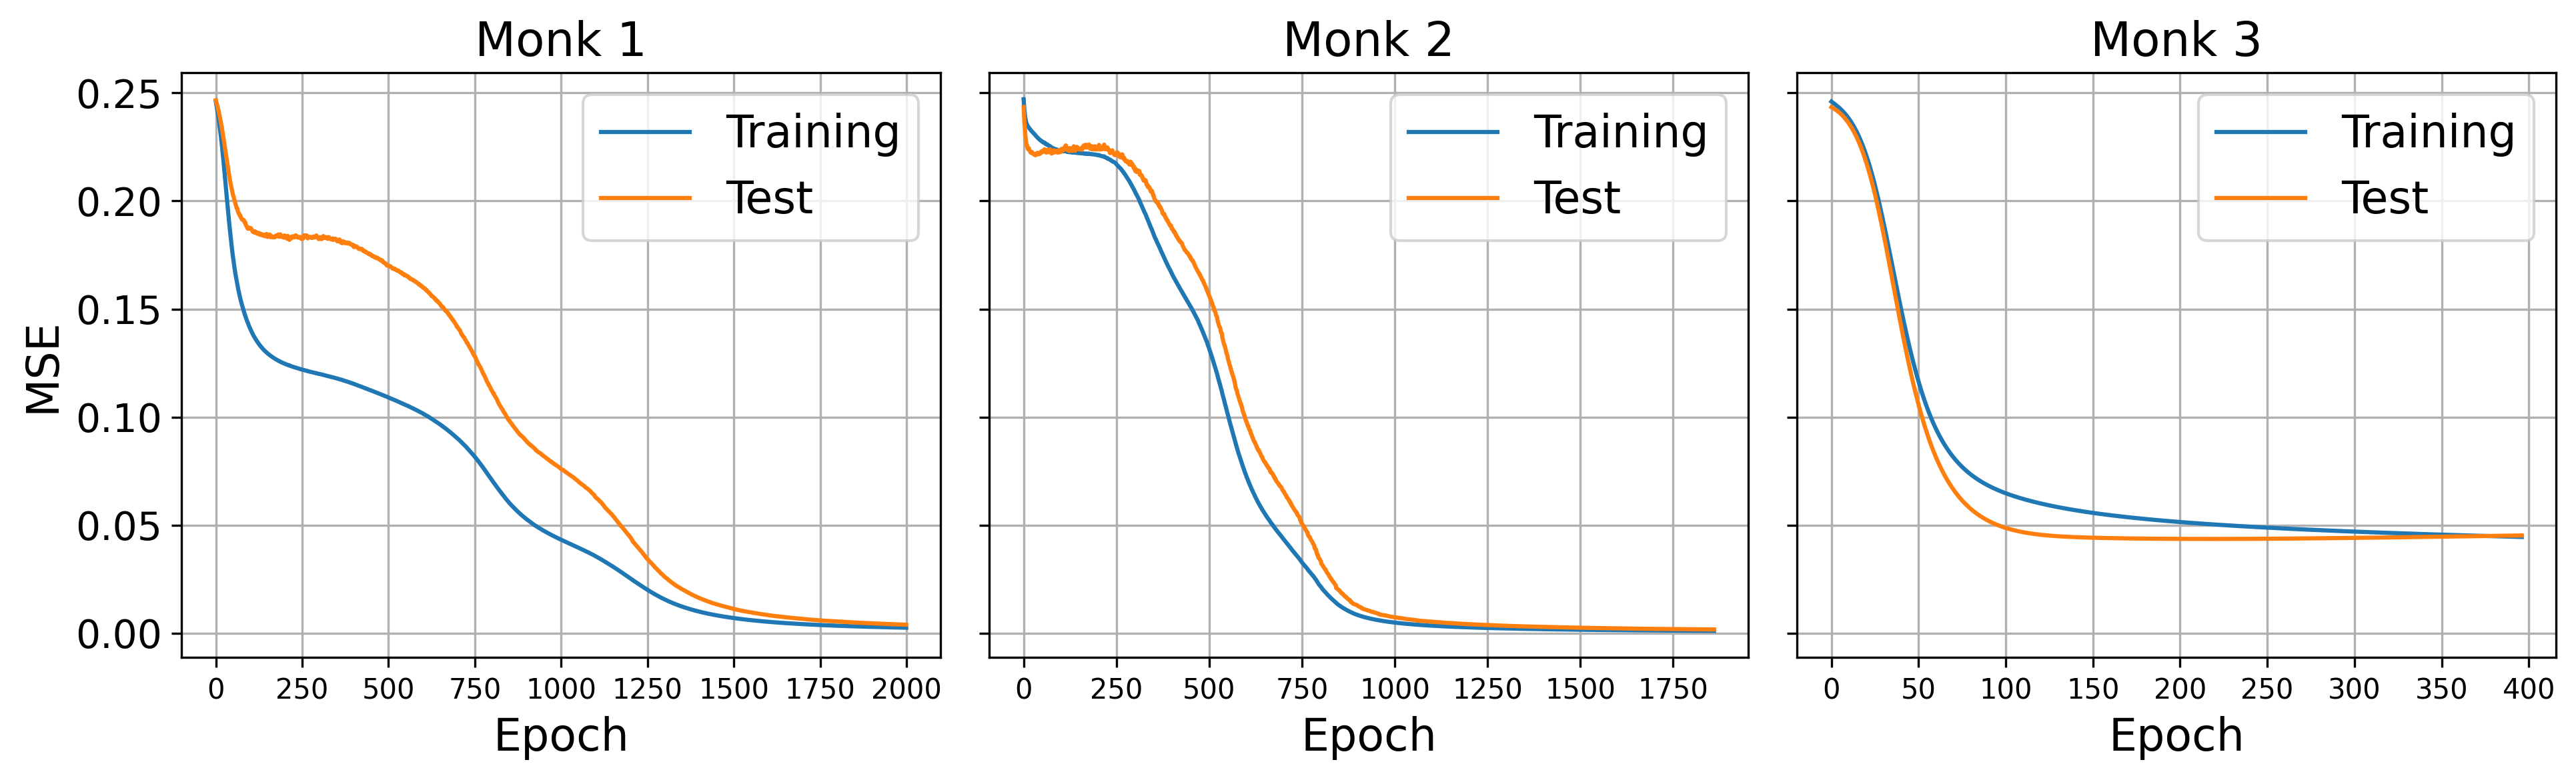

In [2]:
fontsize = 16
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, dpi=300)
axes[0].set_ylabel("MSE", fontsize=fontsize)

yticks = np.linspace(0.0, 0.25, 6)
axes[0].set_yticks(yticks, [f"{t:.2f}" for t in yticks], fontsize=fontsize - 2)

for i, ax in enumerate(axes):
    ax.set_title(f"Monk {i + 1}", fontsize=fontsize + 1)
    res = results[i]
    lc = res["loss"]
    vlc = res["val_loss"]
    ax.plot(lc, label="Training")
    ax.plot(vlc, label="Test")
    ax.set_xlabel("Epoch", fontsize=fontsize)
    ax.grid(True)
    ax.legend(fontsize=fontsize)


plt.tight_layout()
plt.savefig("images/monk_mse.png", format="png", dpi=300)
plt.show()

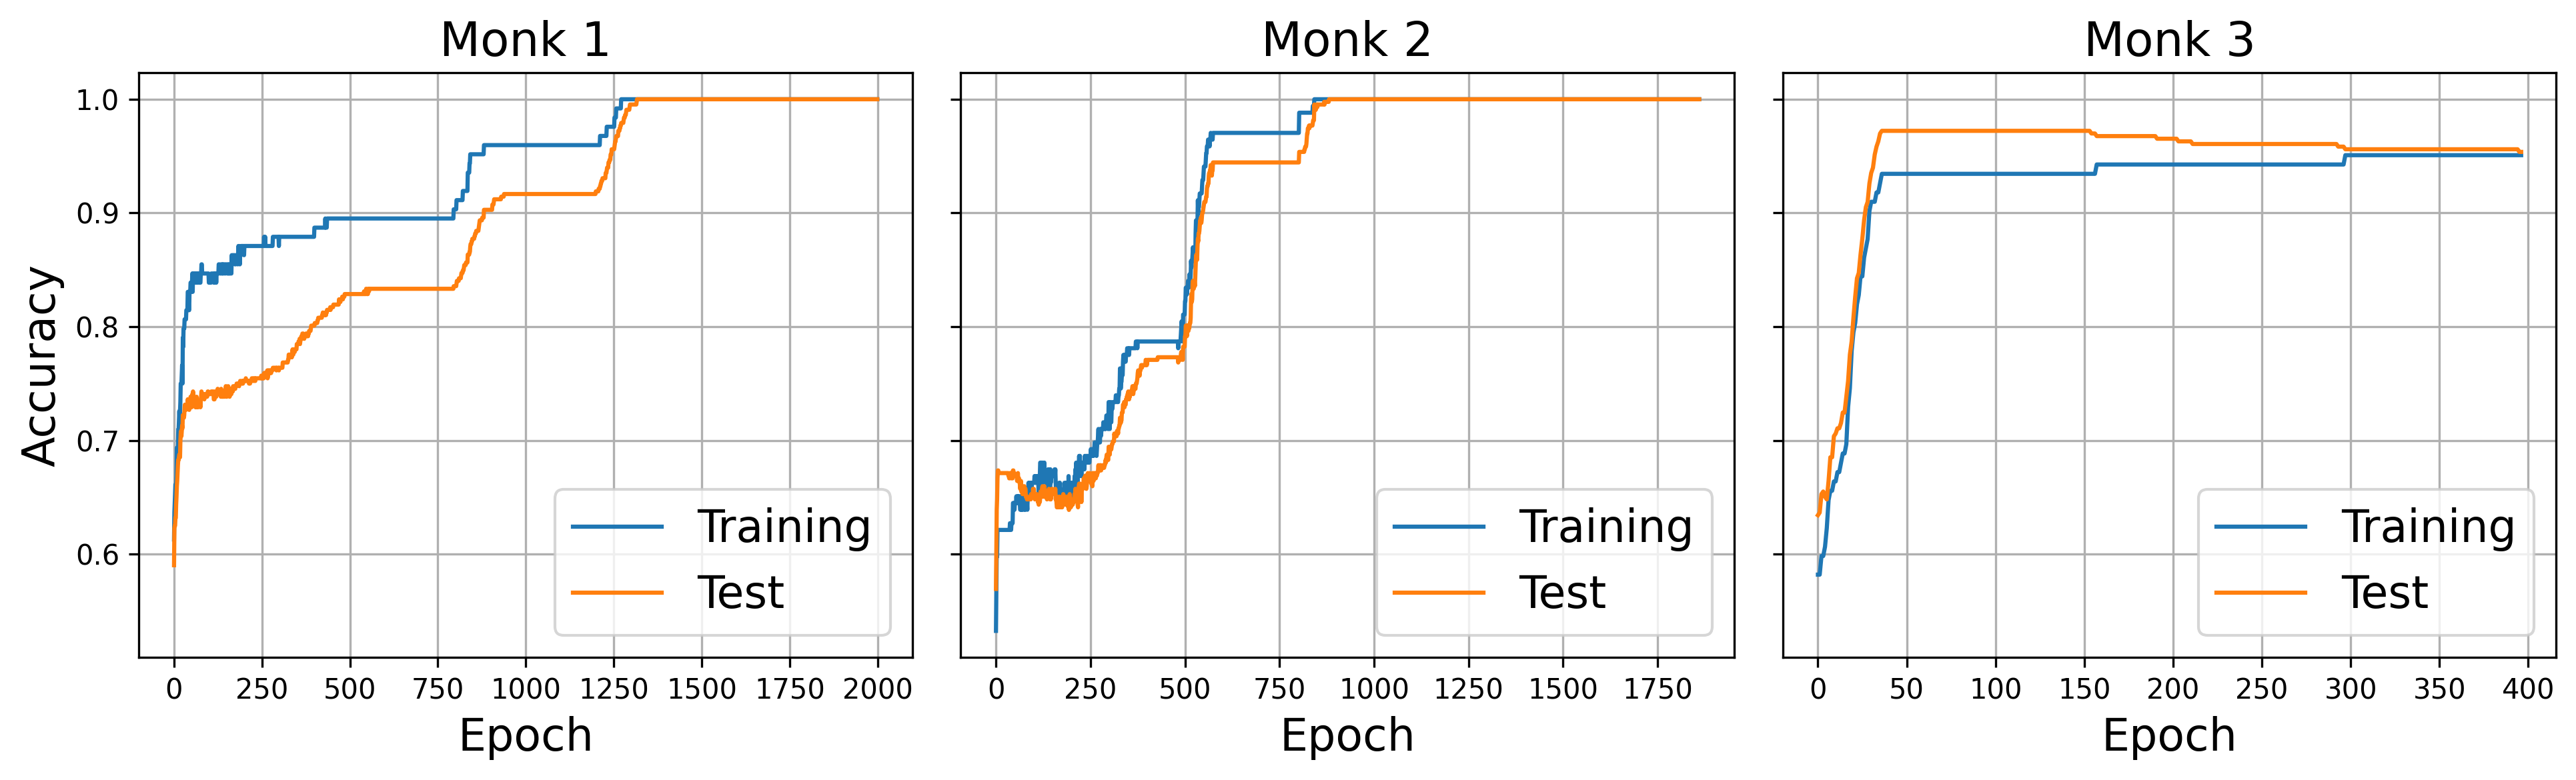

In [3]:
fontsize = 16
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, dpi=300)
axes[0].set_ylabel("Accuracy", fontsize=fontsize)

for i, ax in enumerate(axes):
    ax.set_title(f"Monk {i + 1}", fontsize=fontsize + 1)
    res = results[i]
    lc = res["score"]
    vlc = res["val_score"]
    ax.plot(lc, label="Training")
    ax.plot(vlc, label="Test")
    ax.set_xlabel("Epoch", fontsize=fontsize)
    ax.grid(True)
    ax.legend(fontsize=fontsize)


plt.tight_layout()
plt.savefig("images/monk_accuracy.png", format="png", dpi=300)
plt.show()

In [4]:
with open("../results/curves/cup_stable.json", "r") as fp:
    stable = json.load(fp)

with open("../results/curves/cup_best.json", "r") as fp:
    best = json.load(fp)


with open("../results/curves/keras.json", "r") as fp:
    ks = json.load(fp)

In [5]:
def plot_curve(ax, loss_curves, label):
    max_len = max(len(curve) for curve in loss_curves)
    loss_matrix = np.full((len(loss_curves), max_len), np.nan)
    for i, curve in enumerate(loss_curves):
        loss_matrix[i, : len(curve)] = curve

    mean_loss = np.nanmean(loss_matrix, axis=0)
    std_loss = np.nanstd(loss_matrix, axis=0)
    epochs = np.arange(len(mean_loss))

    ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.25)
    ax.plot(epochs, mean_loss, label=label)

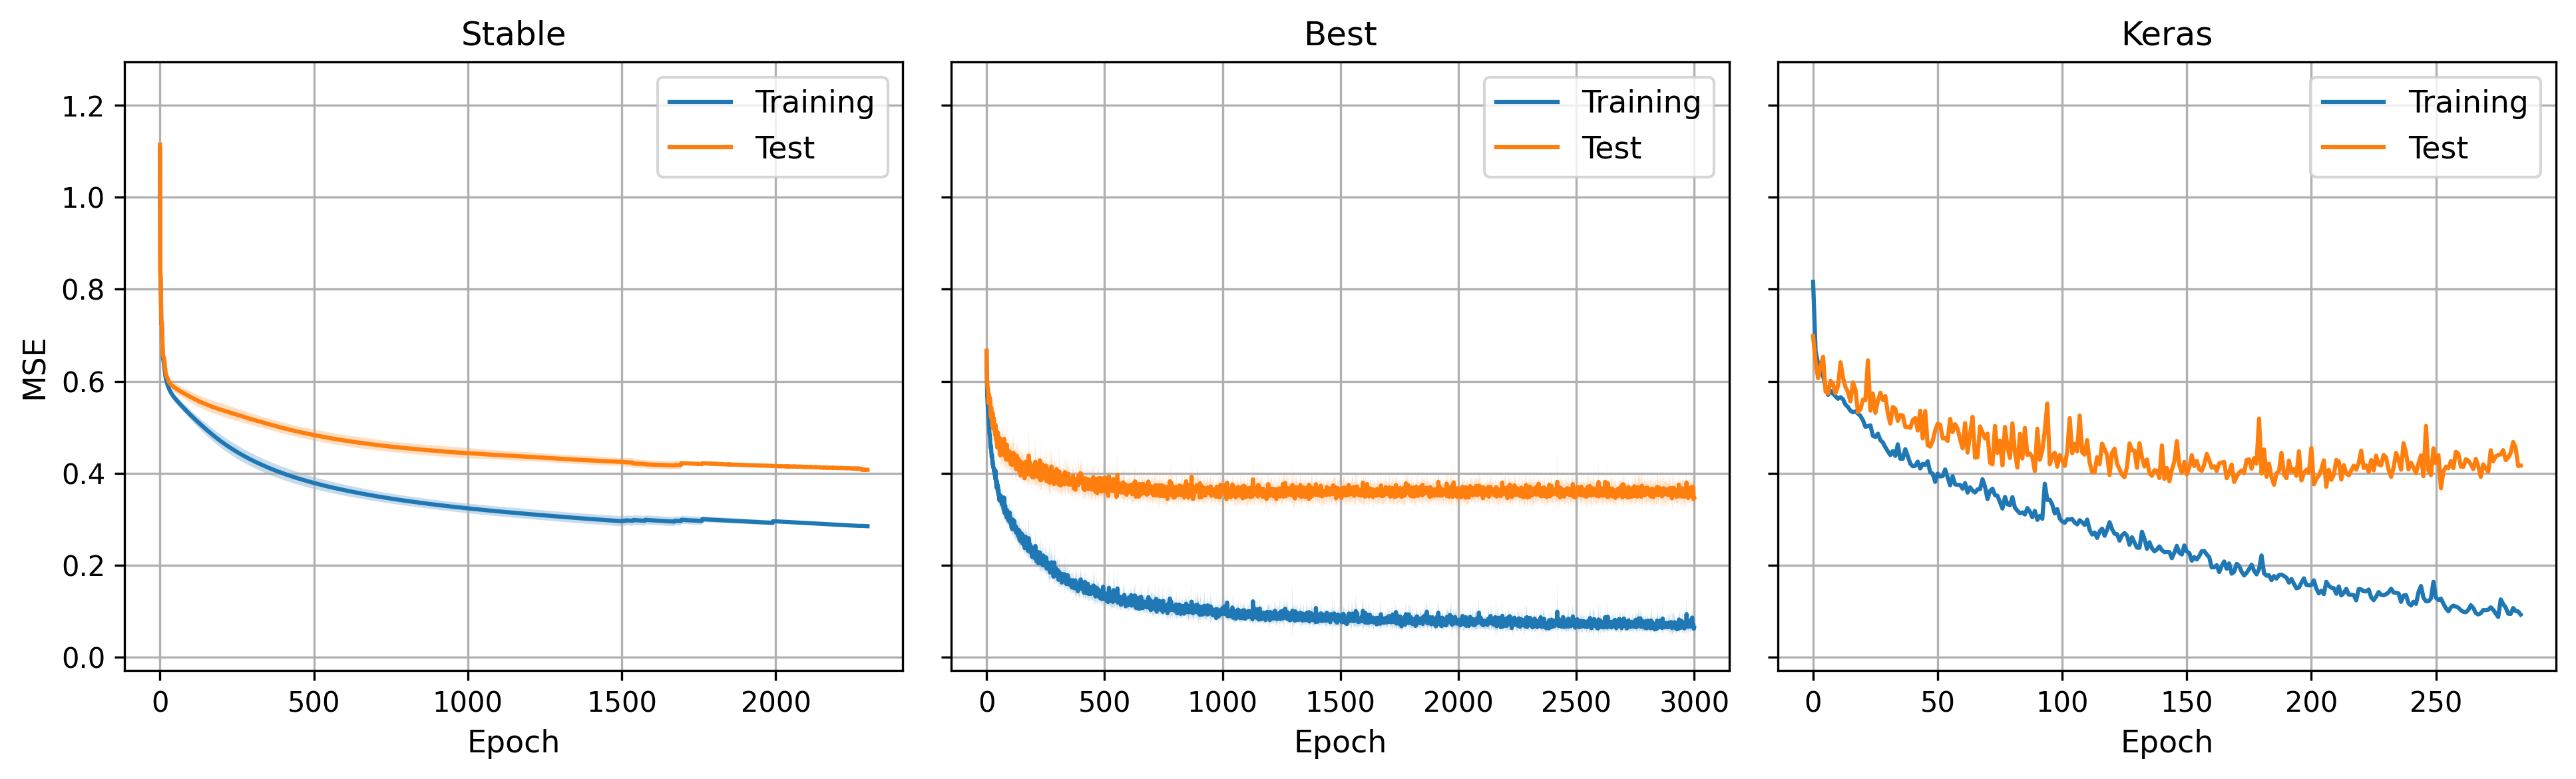

In [11]:
fontsize = 11
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, dpi=300)
axes = axes.flatten()


axes[0].set_ylabel("MSE", fontsize=fontsize)
axes[0].set_title("Stable", fontsize=fontsize + 1)
plot_curve(axes[0], stable["loss_curves"], "Training")
plot_curve(axes[0], stable["val_loss_curves"], "Test")
axes[0].set_xlabel("Epoch", fontsize=fontsize)
axes[0].grid(True)
axes[0].legend(fontsize=fontsize)


axes[1].set_title("Best", fontsize=fontsize + 1)
plot_curve(axes[1], best["loss_curves"], "Training")
plot_curve(axes[1], best["val_loss_curves"], "Test")
axes[1].set_xlabel("Epoch", fontsize=fontsize)
axes[1].grid(True)
axes[1].legend(fontsize=fontsize)


axes[2].set_title("Keras", fontsize=fontsize + 1)
axes[2].plot(ks["loss_curve"], label="Training")
axes[2].plot(ks["val_loss_curve"], label="Test")
axes[2].set_xlabel("Epoch", fontsize=fontsize)
axes[2].grid(True)
axes[2].legend(fontsize=fontsize)

plt.tight_layout()
plt.savefig("images/cup_mse.png", format="png", dpi=300)
plt.show()

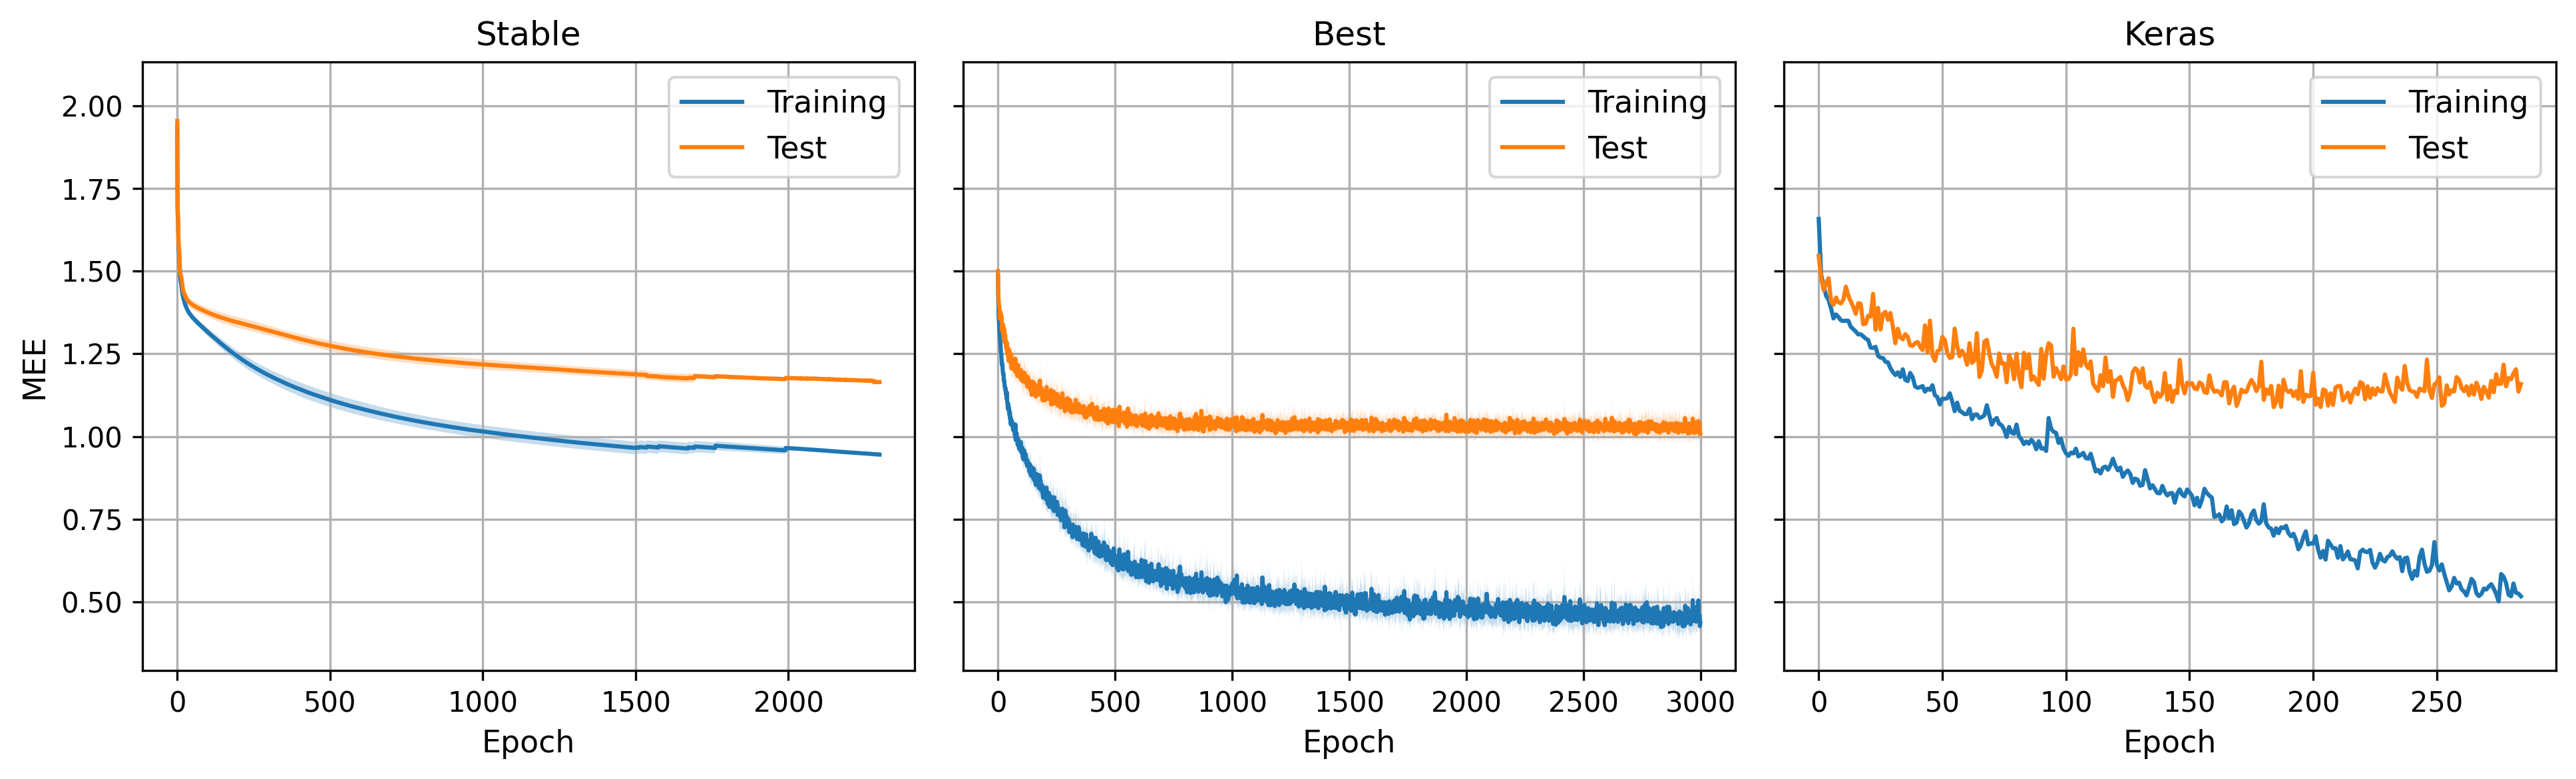

In [17]:
fontsize = 11
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, dpi=300)
axes = axes.flatten()

axes[0].set_ylabel("MEE", fontsize=fontsize)

axes[0].set_title("Stable", fontsize=fontsize + 1)
plot_curve(axes[0], stable["score_curves"], "Training")
plot_curve(axes[0], stable["val_score_curves"], "Test")
axes[0].set_xlabel("Epoch", fontsize=fontsize)
axes[0].grid(True)
axes[0].legend(fontsize=fontsize)


axes[1].set_title("Best", fontsize=fontsize + 1)
plot_curve(axes[1], best["score_curves"], "Training")
plot_curve(axes[1], best["val_score_curves"], "Test")
axes[1].set_xlabel("Epoch", fontsize=fontsize)
axes[1].grid(True)
axes[1].legend(fontsize=fontsize)


axes[2].set_title("Keras", fontsize=fontsize + 1)
axes[2].plot(ks["score_curve"], label="Training")
axes[2].plot(ks["val_score_curve"], label="Test")
axes[2].set_xlabel("Epoch", fontsize=fontsize)
axes[2].grid(True)
axes[2].legend(fontsize=fontsize)


plt.tight_layout()
plt.savefig("images/cup_mee.png", format="png", dpi=300)
plt.show()

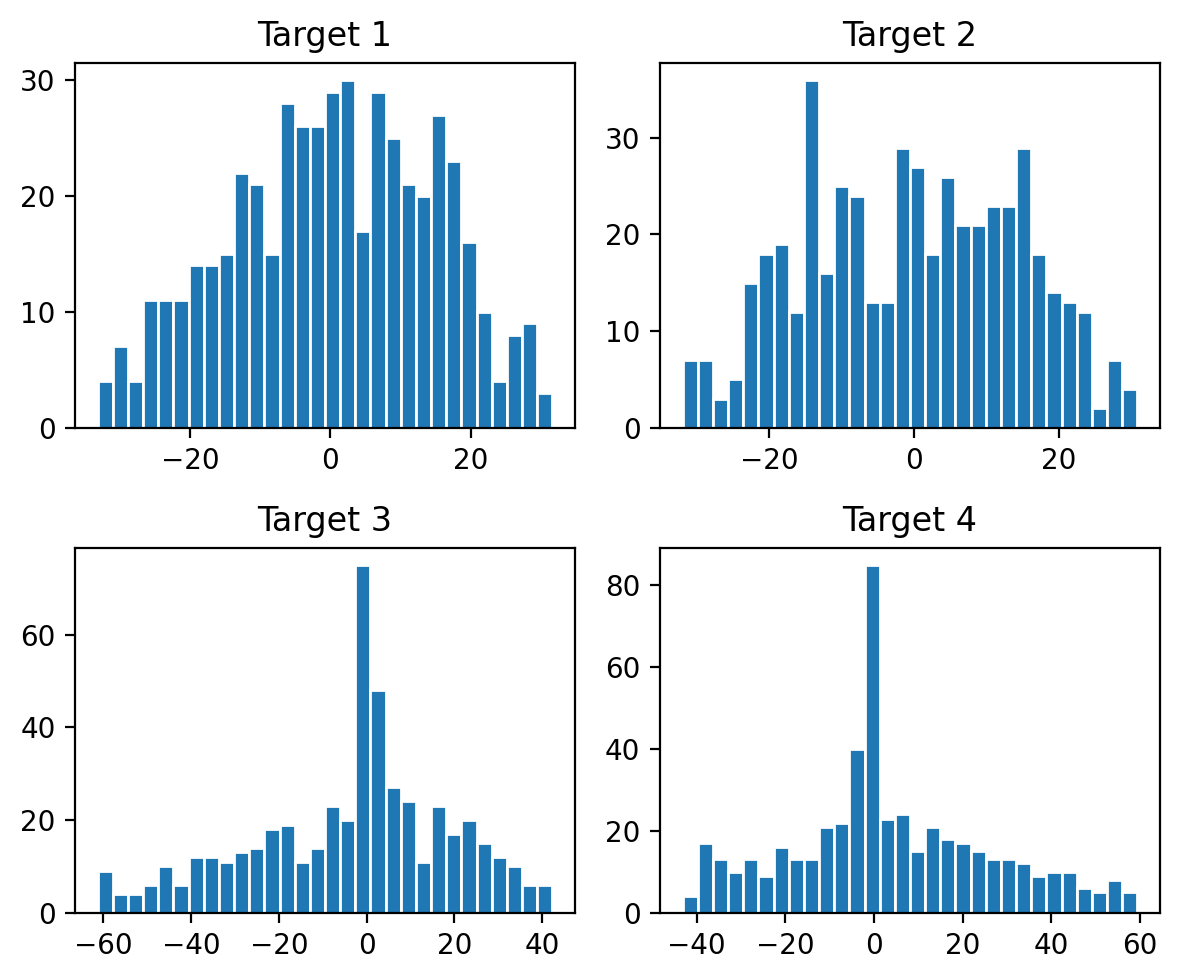

In [ ]:
import pandas as pd


names = ["ID"]
features = [f"feature{i}" for i in range(12)]
targets = [f"target{i}" for i in range(4)]
names.extend(features)
names.extend(targets)

train = pd.read_csv(
    "../datasets/ml_cup_train.csv",
    header=None,
    names=names,
    skiprows=7,
)

# get feature and target columns
X = train.iloc[:, 1:13].to_numpy()
y = train.iloc[:, 13:].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(6, 5), dpi=200)
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.set_title(f"Target {i + 1}")
    ax.hist(y[:, i], bins=30, ec="w")

plt.tight_layout()
plt.savefig("images/target_dists.png", format="png", dpi=300)
plt.show()